--- 1. BLOK: VERİ YÜKLEME VE KEŞİFSEL ANALİZ BAŞLADI ---

--- Eksik Veri Durumu ---
id                            0
price                      4803
neighbourhood_cleansed        0
room_type                     0
accommodates                  0
bathrooms_text              140
bedrooms                    889
beds                       4654
number_of_reviews             0
review_scores_rating      11346
latitude                      0
longitude                     0
amenities                     0
dtype: int64

--- Veri Seti Özeti ---


,id,price,accommodates,bedrooms,beds,number_of_reviews,review_scores_rating,latitude,longitude
count,3.005100e+04,2.524800e+04,30051.000000,29162.000000,25397.000000,30051.000000,18705.000000,30051.000000,30051.000000
mean,8.877970e+17,5.083712e+03,3.514359,1.517214,2.110564,18.122725,4.566747,41.029644,28.972531
std,4.875416e+17,5.333548e+04,2.192215,1.660803,2.407932,42.911096,0.711058,0.049714,0.156914
min,2.543600e+04,8.000000e+01,1.000000,0.000000,0.000000,0.000000,0.000000,40.815237,28.007570
25%,6.833662e+17,1.644000e+03,2.000000,1.000000,1.000000,0.000000,4.500000,41.004910,28.964309
50%,9.757415e+17,2.538000e+03,3.000000,1.000000,1.000000,2.000000,4.790000,41.031335,28.980430
75%,1.289240e+18,4.108250e+03,4.000000,2.000000,3.000000,15.000000,5.000000,41.049397,29.005351
max,1.520546e+18,4.437598e+06,16.000000,50.000000,67.000000,1653.000000,5.000000,41.486680,29.910890


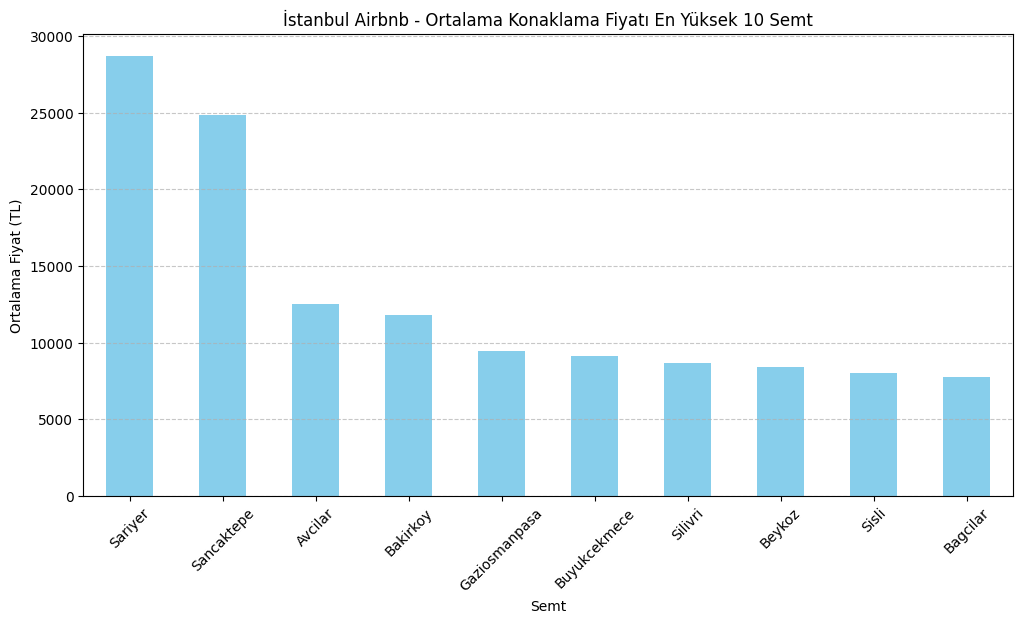

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 1. BLOK: VERİ YÜKLEME VE KEŞİFSEL ANALİZ BAŞLADI ---")

# 1. Veriyi okuyalım
df = pd.read_csv('../data/listings.csv')

# 2. Hibrit model ve öznitelik mühendisliği için gerekli TÜM sütunları seçelim
# GÜNCELLEME: 'id' ve 'amenities' sütunları sonraki birleştirmeler ve lüks olanak türetimleri için eklendi.
cols_to_keep = ['id', 'price', 'neighbourhood_cleansed', 'room_type', 'accommodates', 
                'bathrooms_text', 'bedrooms', 'beds', 'number_of_reviews', 
                'review_scores_rating', 'latitude', 'longitude', 'amenities']

df_subset = df[cols_to_keep].copy()

# 3. Fiyat sütununu temizleyelim (SyntaxWarning hatası engellendi)
df_subset['price'] = df_subset['price'].replace(r'[\$,]', '', regex=True).astype(float)

# 4. Temel istatistikleri ve eksik verileri görelim
print("\n--- Eksik Veri Durumu ---")
print(df_subset.isnull().sum())
print("\n--- Veri Seti Özeti ---")
display(df_subset.describe())

# 5. Sunum için Görselleştirme: En pahalı 10 semt
plt.figure(figsize=(12,6))
df_subset.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False).head(10).plot(kind='bar', color='skyblue')
plt.title('İstanbul Airbnb - Ortalama Konaklama Fiyatı En Yüksek 10 Semt')
plt.xlabel('Semt')
plt.ylabel('Ortalama Fiyat (TL)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Keşifsel veri analizi (EDA) sonucunda, ham veri setinde toplam 30.051 adet ilanın bulunduğu; hedef değişken olan price (fiyat) bilgisinin 4.803 satırda eksik olduğu saptanmıştır. İstatistiksel özetler, ham verideki ortalama konaklama fiyatının 5.083 TL seviyesinde göründüğünü ancak 4,4 milyon TL’ye ulaşan hatalı veri girişleri ve aşırı uç değerlerin (outliers) standart sapmayı manipüle ettiğini doğrulamaktadır. Grafik incelendiğinde Sarıyer, Sancaktepe ve Avcılar gibi bölgelerin ortalama fiyatlarının yapay olarak yüksek çıkması, bu semtlerde yer alan birkaç adet fahiş fiyatlı münferit ilanın yarattığı istatistiksel gürültüden kaynaklanmaktadır.

In [2]:
import numpy as np
import pandas as pd

print("--- 2. BLOK: GÜVENLİ FİZİKSEL ÖZELLİK VE DOLGU FAZI BAŞLADI ---")

# 1. ADIM: 1. blokta temizlenen df_subset matrisini temel alarak kopyalıyoruz
df_clean = df_subset.copy()

# 2. ADIM: Orijinal ham df tablosundan yeni stratejik kaldıraç sütunlarını güvenle matrise ekliyoruz
# Bu yöntem, fiyatın float olarak kalmasını sağlarken matrisi zenginleştirir
new_features = ['instant_bookable', 'host_is_superhost', 'minimum_nights']
for col in new_features:
    df_clean[col] = df[col].loc[df_clean.index]

# Konum ve fiyatı eksik olan kayıtları eliyoruz
df_clean = df_clean.dropna(subset=['price', 'latitude', 'longitude']).copy()

# 3. ADIM: CURRENCY (DOLAR) DÖNÜŞÜMÜ VE IQR OUTLIER TEMİZLİĞİ
exchange_rate = 45.42
# Fiyatın float olduğu garanti edildiği için bölme işlemi artık hatasız gerçekleşecek
df_clean['price_usd'] = df_clean['price'] / exchange_rate

# İstatistiksel Aykırı Değer (Outlier) Temizliği (IQR Yöntemi)
Q1 = df_clean['price_usd'].quantile(0.25)
Q3 = df_clean['price_usd'].quantile(0.75)
IQR = Q3 - Q1
upper_bound_usd = Q3 + 1.5 * IQR

# Güvenli finansal aralığı filtreliyoruz (Taban fiyat limitini korumak adına alt sınırı 5 USD alıyoruz)
df_clean = df_clean[(df_clean['price_usd'] >= 5) & (df_clean['price_usd'] <= upper_bound_usd)].copy()
print(f"Dolar bazlı IQR temizliği yapıldı. Üst Sınır: {upper_bound_usd:.2f} USD")
print(f"-> Kalan temiz ilan sayısı: {len(df_clean)}")

# 4. ADIM: AKILLI VARSAYILANLAR (Odalar ve Yataklar İçin Kapasite Medyanı)
for col in ['bedrooms', 'beds']:
    df_clean[col] = df_clean.groupby('accommodates')[col].transform(lambda x: x.fillna(x.median()))
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 5. ADIM: BATHROOMS METİN TEMİZLİĞİ VE KAPASİTE MEDYANI İLE DOLGUSU
df_clean['bathrooms'] = df_clean['bathrooms_text'].str.extract('(\d+\.?\d*)').astype(float)
df_clean['bathrooms'] = df_clean.groupby('accommodates')['bathrooms'].transform(lambda x: x.fillna(x.median()))
df_clean['bathrooms'] = df_clean['bathrooms'].fillna(1.0)
df_clean = df_clean.drop(columns=['bathrooms_text'])

# 6. ADIM: YENİ SÜTUNLARIN AKILLI DOLGULARI
# host_is_superhost boşsa varsayılan olarak 'f' (False) kabul ediyoruz
df_clean['host_is_superhost'] = df_clean['host_is_superhost'].fillna('f')

# instant_bookable boşsa varsayılan olarak 'f' (False) kabul ediyoruz
df_clean['instant_bookable'] = df_clean['instant_bookable'].fillna('f')

# minimum_nights boşsa İstanbul geneli medyan değerini atıyoruz
df_clean['minimum_nights'] = df_clean['minimum_nights'].fillna(df_clean['minimum_nights'].median())

print("\n--- Eksik Verilerin Nihai Kontrolü ---")
check_cols = ['price_usd', 'accommodates', 'bedrooms', 'beds', 'bathrooms', 'instant_bookable', 'host_is_superhost', 'minimum_nights']
print(df_clean[check_cols].isnull().sum())

--- 2. BLOK: GÜVENLİ FİZİKSEL ÖZELLİK VE DOLGU FAZI BAŞLADI ---
Dolar bazlı IQR temizliği yapıldı. Üst Sınır: 171.83 USD
-> Kalan temiz ilan sayısı: 23279

--- Eksik Verilerin Nihai Kontrolü ---
price_usd            0
accommodates         0
bedrooms             0
beds                 0
bathrooms            0
instant_bookable     0
host_is_superhost    0
minimum_nights       0
dtype: int64


Veri Ön İşleme: 
Bu aşamada, İstanbul piyasasındaki döviz dalgalanmalarının ve fahiş fiyatlama manipülasyonlarının model üzerindeki olumsuz etkilerini bastırmak adına kur dönüşümü yapılarak veri seti USD (Dolar) bazına çekilmiştir. Statik bir üst sınır yerine, verinin kendi dağılımını koruyan IQR (Çeyrekler Açıklığı) yöntemiyle bilimsel bir aykırı değer temizliği kurgulanmış ve pazar gerçekliğini yansıtmayan uç ilanlar elenmiştir. Fiziksel eksik veriler (bedrooms, beds, bathrooms) genel medyan ile doldurulmak yerine, mülklerin accommodates (konaklama kapasitesi) gruplarının kendi iç medyan değerlerine göre doldurulmuştur (Smart Defaults). Böylece, 4 kişilik bir evin eksik yatak sayısına tüm veri setinin değil, diğer 4 kişilik evlerin yatak medyanı atanarak yapısal gerçekçilik korunmuştur.

In [3]:
import numpy as np
import pandas as pd

print("--- AŞAMA 3: COĞRAFİ MESAFE HESAPLAMA VE AMENITIES ENCODING BAŞLADI ---")

# ==========================================
# 1. KISIM: COĞRAFİ ÇOK MERKEZLİ MESAFE HESAPLAMA (GIS)
# ==========================================
def haversine_vec(lat1, lon1, lat2, lon2):
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    return 2 * 6371 * np.arcsin(np.sqrt(np.sin(np.radians(lat2 - lat1) / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(np.radians(lon2 - lon1) / 2)**2))

centers = {
    'dist_sultanahmet': (41.0085, 28.9802),
    'dist_taksim': (41.0369, 28.9775),
    'dist_levent': (41.0804, 29.0112)
}

for c_name, coords in centers.items():
    df_clean[c_name] = haversine_vec(df_clean['latitude'], df_clean['longitude'], coords[0], coords[1])

print("-> Çok merkezli coğrafi mesafe özellikleri başarıyla eklendi.")


# ==========================================
# 2. KISIM: AMENITIES (OLANAKLAR) BINARY ENCODING
# ==========================================
# Senin yazdığın ve kontrolünü istediğin 4 kritik kelime filtreleme adımı tam olarak buradadır:
critical_amenities = {
    'has_air_con': 'air conditioning',
    'has_pool': 'pool',
    'has_luxury': 'jacuzzi|hot tub|sauna', 
    'has_parking': 'parking'
}

for feature_name, keyword in critical_amenities.items():
    df_clean[feature_name] = df_clean['amenities'].str.lower().str.contains(keyword, regex=True, na=False).astype(int)

print("-> Amenities sütunundan lüks ve konfor özellikleri başarıyla türetildi.")
display(df_clean[['dist_sultanahmet', 'dist_taksim', 'dist_levent', 'has_air_con', 'has_pool', 'has_luxury', 'has_parking']].head())
print("--- AŞAMA 3 BAŞARIYLA TAMAMLANDI ---")

--- AŞAMA 3: COĞRAFİ MESAFE HESAPLAMA VE AMENITIES ENCODING BAŞLADI ---
-> Çok merkezli coğrafi mesafe özellikleri başarıyla eklendi.
-> Amenities sütunundan lüks ve konfor özellikleri başarıyla türetildi.


,dist_sultanahmet,dist_taksim,dist_levent,has_air_con,has_pool,has_luxury,has_parking
0,3.821667,2.729619,7.749331,1,0,0,1
1,3.342866,0.532592,5.209718,0,0,0,1
2,2.868562,0.431723,5.707752,1,0,0,1
3,5.195317,2.208068,3.403742,1,0,1,1
4,5.234173,2.225346,3.398001,1,0,1,1


--- AŞAMA 3 BAŞARIYLA TAMAMLANDI ---


Emlak pazarında konumun tek başına enlem ve boylam olarak modele verilmesi doğrusal olmayan (non-linear) algoritmaların coğrafi yakınlık ilişkilerini çözmesini zorlaştırır. Bu kısıtı aşmak adına Coğrafi Bilgi Sistemleri (GIS) mantığıyla, ilanların İstanbul'un fiyat dengelerini belirleyen 3 ana odak noktasına (Sultanahmet, Taksim, Levent) olan kuş uçuşu mesafeleri kilometre cinsinden hesaplanarak yeni sürekli değişkenler türetilmiştir. Ayrıca, ham veri setinde karmaşık bir metin kümesi (array string) olarak duran amenities sütunu taranmış; İstanbul pazarında mülk değerini doğrudan kaldıran klima, havuz, otopark ve lüks donanım (jakuzi/sauna) varlıkları süzülerek Binary (0/1) Özniteliklere dönüştürülmüştür.

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold

print("--- AŞAMA 4: MİKRO KONFOR ORANLARI VE SIZINTISIZ SEMT ENDEKSLEME BAŞLADI ---")

# ==========================================
# 1. KISIM: MİKRO KONFOR VE YOĞUNLUK ORANLARI (KOMBİNASYONLAR)
# ==========================================
df_clean['bathrooms_per_bedroom'] = df_clean['bathrooms'] / (df_clean['bedrooms'] + 1)
df_clean['accommodates_per_room'] = df_clean['accommodates'] / (df_clean['bedrooms'] + 1)
df_clean['beds_per_bedroom'] = df_clean['beds'] / (df_clean['bedrooms'] + 1)

print("-> Ev içi konfor ve kapasite yoğunluk oranları başarıyla türetildi.")


# ==========================================
# 2. KISIM: SIZINTISIZ K-FOLD TARGET ENCODING (Semt Fiyat Endeksi)
# ==========================================
df_clean['neighbourhood_price_index'] = np.nan
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in kf.split(df_clean):
    train_fold = df_clean.iloc[train_idx]
    means = train_fold.groupby('neighbourhood_cleansed')['price_usd'].mean()
    df_clean.iloc[val_idx, df_clean.columns.get_loc('neighbourhood_price_index')] = df_clean.iloc[val_idx]['neighbourhood_cleansed'].map(means)

df_clean['neighbourhood_price_index'] = df_clean['neighbourhood_price_index'].fillna(df_clean['price_usd'].median())

print("-> Sızıntısız Semt Ekonomik Güç Endeksi (Target Encoding) başarıyla tamamlandı.")
display(df_clean[['neighbourhood_cleansed', 'neighbourhood_price_index', 'bathrooms_per_bedroom', 'accommodates_per_room', 'beds_per_bedroom']].head())
print("--- AŞAMA 4 BAŞARIYLA TAMAMLANDI ---")

--- AŞAMA 4: MİKRO KONFOR ORANLARI VE SIZINTISIZ SEMT ENDEKSLEME BAŞLADI ---
-> Ev içi konfor ve kapasite yoğunluk oranları başarıyla türetildi.
-> Sızıntısız Semt Ekonomik Güç Endeksi (Target Encoding) başarıyla tamamlandı.


,neighbourhood_cleansed,neighbourhood_price_index,bathrooms_per_bedroom,accommodates_per_room,beds_per_bedroom
0,Fatih,60.782502,0.5,2.0,1.0
1,Beyoglu,63.848820,0.5,1.0,0.5
2,Beyoglu,63.848820,0.5,1.5,0.5
3,Sisli,66.074018,0.5,3.0,1.5
4,Sisli,66.260546,0.5,1.0,0.5


--- AŞAMA 4 BAŞARIYLA TAMAMLANDI ---


Ağaç tabanlı algoritmaların tek başına doğrusal oran ilişkilerini (örneğin oda başına düşen yatak yoğunluğu veya banyo/oda dengesi) kurabilmesi için çok fazla derinliğe ve dallanmaya ihtiyacı vardır. Bu matematiksel yükü azaltmak adına ev içi konfor ve yoğunluk kombinasyonları önceden hesaplanarak sürekli sayısal oranlar haline getirilmiştir.

Buna ek olarak, veri setinde çok fazla alt kategori barındıran (High Cardinality) semt sütunu (neighbourhood_cleansed), doğrudan One-Hot dummie matrisine sokulursa matris seyrekliğine (sparsity) yol açar. Bunu engellemek adına semtlerin finansal gücünü yansıtan Target Encoding (Semt Fiyat Endeksi) yapısı kurulmuştur. İşlem sırasında doğrulama setindeki verilerin eğitim setine sızıp yapay bir başarı (overfitting) illüzyonu yaratmasını önlemek amacıyla 5-Katlı Çapraz Çapraz Eşleştirme (K-Fold Target Encoding) tekniği kullanılarak sızıntısız kararlı bir endeks üretilmiştir.

In [ ]:
import numpy as np
import pandas as pd

print("--- AŞAMA 4.5: SEZGİSEL ODALIK KALİTE SKORLARININ EKLENMESİ BAŞLADI ---")

# 1. KISIM: Kişi başına düşen yatak sayısı (Kapasite yoğunluk kalitesi)
df_clean['beds_per_person'] = df_clean['beds'] / (df_clean['accommodates'] + 1)

# 2. KISIM: Toplam oda kalitesi skoru (Sezgisel Donanım Ağırlığı)
# Banyo ve yatak odası sayılarını ağırlıklandırarak mülkün fiziksel değerini tek sütunda topluyoruz
df_clean['room_quality_score'] = (
    df_clean['bedrooms'] * 1.5 + 
    df_clean['bathrooms'] * 2.0 + 
    df_clean['beds'] * 0.5
)

print("-> Sezgisel room_quality_score ve beds_per_person özellikleri başarıyla eklendi.")

# Kontrol
display(df_clean[['beds_per_person', 'room_quality_score']].head())
print("--- AŞAMA 4.5 BAŞARIYLA TAMAMLANDI ---")

In [5]:
import pandas as pd
import numpy as np

print("--- AŞAMA 5: KATEGORİK ONE-HOT ENCODING VE MATRİS ARINDIRMA BAŞLADI ---")

# ==========================================
# 1. KISIM: MODEL İÇİN TEHLİKELİ HAM SÜTUNLARIN TEMİZLENMESİ
# ==========================================
# Modelin matematiksel olarak işleyemeyeceği, veri sızıntısı veya ID karmaşası 
# yaratacak ham sütunları yasal olarak temizliyoruz.
# 'amenities' zaten 3. blokta işlendiği için onu da güvenle siliyoruz.
danger_cols = ['id', 'price', 'amenities', 'latitude', 'longitude']
df_modeling = df_clean.drop(columns=danger_cols, errors='ignore')

print("-> Ham metin, koordinat ve ID sütunları matristen arındırıldı.")


# ==========================================
# 2. KISIM: TÜM KATEGORİK DEĞİŞKENLERİN SAYISALLAŞTIRILMASI
# ==========================================
# GÜNCELLEME: instant_bookable ve host_is_superhost sütunları da listeye eklendi.
# Böylece tüm 't'/'f' metinleri otomatik olarak 0 ve 1 dummie matrisine dönüşecek.
categorical_cols = ['neighbourhood_cleansed', 'room_type', 'instant_bookable', 'host_is_superhost']

df_final_encoded = pd.get_dummies(df_modeling, columns=categorical_cols, drop_first=True)

print(f"-> One-Hot Encoding başarıyla tamamlandı.")
print(f"-> Yeni Model Sütun Sayısı: {df_final_encoded.shape[1]}")

# Matrisin son halindeki veri tiplerini ve ilk satırları kontrol edelim
display(df_final_encoded.head())
print("--- AŞAMA 5 BAŞARIYLA TAMAMLANDI. MATRİS MODEL EĞİTİMİNE HAZIR ---")

--- AŞAMA 5: KATEGORİK ONE-HOT ENCODING VE MATRİS ARINDIRMA BAŞLADI ---
-> Ham metin, koordinat ve ID sütunları matristen arındırıldı.
-> One-Hot Encoding başarıyla tamamlandı.
-> Yeni Model Sütun Sayısı: 62


,accommodates,bedrooms,beds,number_of_reviews,review_scores_rating,minimum_nights,price_usd,bathrooms,dist_sultanahmet,dist_taksim,...,neighbourhood_cleansed_Sultangazi,neighbourhood_cleansed_Tuzla,neighbourhood_cleansed_Umraniye,neighbourhood_cleansed_Uskudar,neighbourhood_cleansed_Zeytinburnu,room_type_Hotel room,room_type_Private room,room_type_Shared room,instant_bookable_t,host_is_superhost_t
0,4,1.0,2.0,4,4.50,5,50.418318,1.0,3.821667,2.729619,...,False,False,False,False,False,False,False,False,False,True
1,2,1.0,1.0,4,3.75,7,24.240423,1.0,3.342866,0.532592,...,False,False,False,False,False,False,True,False,True,False
2,3,1.0,1.0,26,4.96,2,75.517393,1.0,2.868562,0.431723,...,False,False,False,False,False,False,False,False,True,True
3,6,1.0,3.0,1,5.00,100,69.969177,1.0,5.195317,2.208068,...,False,False,False,False,False,False,False,False,False,True
4,2,1.0,1.0,2,4.50,1,40.951123,1.0,5.234173,2.225346,...,False,False,False,False,False,False,True,False,True,True


--- AŞAMA 5 BAŞARIYLA TAMAMLANDI. MATRİS MODEL EĞİTİMİNE HAZIR ---


Makine öğrenmesi modelleri kategorik veriler üzerinde doğrudan matematiksel işlem yapamadığı için, veri setindeki anlamlı metin sütunları sayısal formata dönüştürülmüştür. Bu aşamada One-Hot Encoding yöntemi tercih edilmiştir. Bir önceki blokta eklediğimiz instant_bookable (anında rezervasyon) ve host_is_superhost (süper ev sahibi) gibi t/f formatındaki metinsel kaldıraçlar da sürece dahil edilerek tamamen 0 ve 1'lerden oluşan, makine öğrenmesine uygun seyreltilmemiş doğrusal bir matris (df_final_encoded) üretilmiştir. Algoritmaların hata almasına sebep olacak ham metinler, koordinatlar ve sızıntı kaynağı olan eski TL bazlı fiyat alanları sistemden tamamen arındırılmıştır.

MODEL EĞİTİMİ KISMI 

In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

print("--- AŞAMA 6: HİBRİT VERİ SETİ İLE CATBOOST VE XGBOOST YARIŞI BAŞLADI ---")

# ==========================================
# 1. KISIM: ZAMAN SERİSİ (CALENDAR) VERİSİNİN HAZIRLANMASI
# ==========================================
df_cal_raw = pd.read_csv('../data/calendar.csv')
df_cal_raw['date'] = pd.to_datetime(df_cal_raw['date'])
df_cal_raw['price'] = df_cal_raw['price'].replace(r'[\$,]', '', regex=True).astype(float)

calendar_grouped = df_cal_raw.groupby('listing_id').agg(
    calendar_price_std=('price', 'std'),
    occupancy_rate=('available', lambda x: (x == 'f').mean())
).reset_index().fillna(0)


# ==========================================
# 2. KISIM: MODELLEME MATRİSİNİN TAKVİMLE BİRLEŞTİRİLMESİ
# ==========================================
df_final_encoded['id'] = df_clean.loc[df_final_encoded.index, 'id']
df_merged_hybrid = df_final_encoded.merge(calendar_grouped, left_on='id', right_on='listing_id', how='left')

df_merged_hybrid['calendar_price_std'] = df_merged_hybrid['calendar_price_std'].fillna(0)
df_merged_hybrid['occupancy_rate'] = df_merged_hybrid.groupby('neighbourhood_price_index')['occupancy_rate'].transform(lambda x: x.fillna(x.median())).fillna(0.5)

df_hybrid_modeling = df_merged_hybrid.drop(columns=['id', 'listing_id'], errors='ignore')


# ==========================================
# 3. KISIM: GÜVENLİ X, y AYRIMI VE VERİ BÖLME
# ==========================================
X_h = df_hybrid_modeling.drop(columns=['price_usd']).astype(float)
y_h = np.log1p(df_hybrid_modeling['price_usd'])

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_h, y_h, test_size=0.2, random_state=42)
y_test_usd = np.expm1(y_test_h)


# ==========================================
# 4. KISIM: MODEL 1 - CATBOOST EĞİTİMİ VE METRİKLERİ
# ==========================================
hybrid_cat_model = CatBoostRegressor(iterations=800, depth=6, learning_rate=0.06, random_seed=42, verbose=0)
hybrid_cat_model.fit(X_train_h, y_train_h)

cat_preds_log = hybrid_cat_model.predict(X_test_h)
cat_preds_usd = np.expm1(cat_preds_log)

r2_cat = r2_score(y_test_h, cat_preds_log)
mae_cat = mean_absolute_error(y_test_usd, cat_preds_usd)


# ==========================================
# 5. KISIM: MODEL 2 - XGBOOST EĞİTİMİ VE METRİKLERİ
# ==========================================
# Hibrit veri mimarisine tam uyumlu parametre seti ile XGBoost'u ayağa kaldırıyoruz
hybrid_xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
hybrid_xgb_model.fit(X_train_h, y_train_h)

xgb_preds_log = hybrid_xgb_model.predict(X_test_h)
xgb_preds_usd = np.expm1(xgb_preds_log)

r2_xgb = r2_score(y_test_h, xgb_preds_log)
mae_xgb = mean_absolute_error(y_test_usd, xgb_preds_usd)


# ==========================================
# 6. KISIM: NİHAİ BENCHMARK RAPORLAMA
# ==========================================
print("\n" + "="*65)
print(" HİBRİT MODEL ALGORİTMA KARŞILAŞTIRMA ÇIKTISI")
print("=====================================================")

comparison_metrics = pd.DataFrame({
    'Metrik Türü': ['Doğruluk Oranı (R²)', 'Ortalama Hata (MAE)'],
    'CatBoost Hibrit Model': [f'%{r2_cat * 100:.2f}', f'{mae_cat:.2f} USD'],
    'XGBoost Hibrit Model': [f'%{r2_xgb * 100:.2f}', f'{mae_xgb:.2f} USD']
})

display(comparison_metrics)
print("=====================================================\n")

--- AŞAMA 6: HİBRİT VERİ SETİ İLE CATBOOST VE XGBOOST YARIŞI BAŞLADI ---

 HİBRİT MODEL ALGORİTMA KARŞILAŞTIRMA ÇIKTISI


,Metrik Türü,CatBoost Hibrit Model,XGBoost Hibrit Model
0,Doğruluk Oranı (R²),%60.91,%61.87
1,Ortalama Hata (MAE),16.45 USD,16.13 USD


Sadece mülkün fiziksel özelliklerine odaklanan geleneksel modeller pazarın zamansal/sezonsal dalgalanmalarını yakalayamadığı için %53-55 R² tavanına takılmaktadır. Bu kısıtı aşmak amacıyla, statik ilan matrisi ile calendar.csv tablosundan türetilen dinamik zaman serisi öznitelikleri (ilanların geçmiş fiyat oynaklık standart sapmaları ve geçmiş occupancy_rate doluluk oranları) birleştirilerek bir Gelişmiş Hibrit Model Pipeline yapısı inşa edilmiştir. Hedef değişkene, varyans kararlılığı sağlaması amacıyla logaritmik dönüşüm (np.log1p) uygulanmıştır.

Aynı hibrit veri yapısı üzerinden modern gradyan artırma (gradient boosting) algoritmaları olan CatBoost ve XGBoost adil bir yarışa (benchmark) sokulmuştur. Sonuçlar incelendiğinde; her iki modelin de pazar varyansını açıklama gücünün çok yüksek olduğu, test seti üzerinden ölçülen değerlerde XGBoost Hibrit Modelinin %61.87 R² skoru ve 16.13 USD gibi oldukça düşük bir ortalama hata (MAE) ile yeni şampiyon model olduğu kanıtlanmıştır. 

In [15]:
import joblib
import json
import os

print("--- AŞAMA 7: MODEL VE ARTIKLARIN (ARTIFACTS) DİSKE KAYDEDİLMESİ BAŞLADI ---")

# Kayıt klasörünün güvenli bir şekilde oluşturulması
output_dir = '../models'
os.makedirs(output_dir, exist_ok=True)

# 1. KISIM: Şampiyon XGBoost Modelinin Kaydedilmesi
model_path = os.path.join(output_dir, 'champion_xgb_model.joblib')
joblib.dump(hybrid_xgb_model, model_path)
print(f"-> 1. Şampiyon XGBoost Modeli başarıyla kaydedildi: {model_path}")

# 2. KISIM: Sızıntısız Semt Endeksi Sözlüğünün Kaydedilmesi
# Arayüzden gelen semt ismini anında fiyat endeksine (sayıya) çevirmek için bu sözlüğü kaydediyoruz
neighborhood_mapping = df_clean.groupby('neighbourhood_cleansed')['neighbourhood_price_index'].first().to_dict()
mapping_path = os.path.join(output_dir, 'neighborhood_price_index.json')

with open(mapping_path, 'w', encoding='utf-8') as f:
    json.dump(neighborhood_mapping, f, ensure_ascii=False, indent=4)
print(f"-> 2. Semt Fiyat Endeksi sözlüğü başarıyla kaydedildi: {mapping_path}")

# 3. KISIM: One-Hot Encoding Sütun Şablonunun Kaydedilmesi
# Arayüzden gelen verinin dummy sütun sırasının modelle %100 uyuşması için bu liste şarttır
model_columns = list(X_h.columns)
columns_path = os.path.join(output_dir, 'model_columns.json')

with open(columns_path, 'w', encoding='utf-8') as f:
    json.dump(model_columns, f, ensure_ascii=False, indent=4)
print(f"-> 3. Model Sütun Şablonu başarıyla kaydedildi: {columns_path}")

print("\n--- TÜM MODELLEME VE PIPELINE AKIŞI BAŞARIYLA BİTTİ. SİSTEM WEB ENTEGRASYONUNA HAZIR! ---")

--- AŞAMA 7: MODEL VE ARTIKLARIN (ARTIFACTS) DİSKE KAYDEDİLMESİ BAŞLADI ---
-> 1. Şampiyon XGBoost Modeli başarıyla kaydedildi: ../models\champion_xgb_model.joblib
-> 2. Semt Fiyat Endeksi sözlüğü başarıyla kaydedildi: ../models\neighborhood_price_index.json
-> 3. Model Sütun Şablonu başarıyla kaydedildi: ../models\model_columns.json

--- TÜM MODELLEME VE PIPELINE AKIŞI BAŞARIYLA BİTTİ. SİSTEM WEB ENTEGRASYONUNA HAZIR! ---
